In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv('student-mat.csv', sep=';')
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
data = data.drop(columns = ['address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'famsup'])

In [ ]:
maps = {'GP': 0, 'MS': 1}
data['school'] = data['school'].map(maps)

In [ ]:
data['school'].value_counts()

,count
school,
0,349
1,46


In [ ]:
data.columns

Index(['school', 'sex', 'age', 'traveltime', 'studytime', 'failures',
       'schoolsup', 'paid', 'activities', 'nursery', 'higher', 'internet',
       'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
       'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [ ]:
gen = {'F': 0, 'M': 1}
data['sex'] = data['sex'].map(gen)

In [ ]:
data['traveltime'].value_counts()

,count
traveltime,
1,257
2,107
3,23
4,8


In [ ]:
data['traveltime'] = data['traveltime'].apply(lambda x:0 if x == 1 else 1)

In [ ]:
data['traveltime'].value_counts()

,count
traveltime,
0,257
1,138


In [ ]:
data['studytime'].value_counts()

,count
studytime,
2,198
1,105
3,65
4,27


In [ ]:
data['studytime'] = data['studytime'].apply(lambda x:0 if x == 1 else 1)

In [ ]:
data['studytime'].value_counts()

,count
studytime,
1,290
0,105


In [ ]:
data['failures'].value_counts()

,count
failures,
0,312
1,50
2,17
3,16


In [ ]:
data['failures'] = data['failures'].apply(lambda x :x if x <2 else 2 )

In [ ]:
data['failures'].value_counts()

,count
failures,
0,312
1,50
2,33


In [ ]:
data['schoolsup'].value_counts()

,count
schoolsup,
no,344
yes,51


In [ ]:
data['schoolsup'] = data['schoolsup'].map({'yes': 1, 'no': 0})

In [ ]:
data['schoolsup'].value_counts()

,count
schoolsup,
0,344
1,51


In [ ]:
data['paid'] = data['paid'].map({'yes': 1, 'no': 0})
data['paid'].value_counts()

,count
paid,
0,214
1,181


In [ ]:
data['activities'] = data['activities'].map({'yes': 1, 'no': 0})
data['activities'].value_counts()

,count
activities,
1,201
0,194


In [ ]:
data['nursery'] = data['nursery'].map({'yes': 1, 'no': 0})
data['nursery'].value_counts()

,count
nursery,
1,314
0,81


In [ ]:
data = data.replace({'yes': 1, 'no': 0})

/tmp/ipython-input-679574670.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({'yes': 1, 'no': 0})


In [ ]:
data['famrel'].value_counts()

,count
famrel,
4,195
5,106
3,68
2,18
1,8


In [ ]:
data['famrel'] =data['famrel'].apply(lambda x :0 if x <= 2 else (1 if x ==3 else 2))

In [ ]:
data['freetime'].value_counts()

,count
freetime,
3,157
4,115
2,64
5,40
1,19


In [ ]:
data['freetime'] = data['freetime'].apply(lambda x: 0 if x <= 3 else 1)

In [ ]:
data['goout'].value_counts()

,count
goout,
3,130
2,103
4,86
5,53
1,23


In [ ]:
data['goout'] = data['goout'].apply(lambda x: 0 if x <= 3 else 1)

In [ ]:
data['goout'].value_counts()

,count
goout,
0,256
1,139


In [ ]:
data['Dalc'].value_counts()

,count
Dalc,
1,276
2,75
3,26
5,9
4,9


In [ ]:
data['Dalc'] = data['Dalc'].apply(lambda x:0 if x <= 2 else 1)

In [ ]:
data['Dalc'].value_counts()

,count
Dalc,
0,395


In [ ]:
data.drop('Dalc', axis = 1, inplace = True)

In [ ]:
data.drop('Walc', axis =1 , inplace = True)

In [ ]:
data['health'].value_counts()

,count
health,
5,146
3,91
4,66
1,47
2,45


In [ ]:
data.head()

,school,sex,age,traveltime,studytime,failures,schoolsup,paid,activities,nursery,...,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
0,0,0,18,1,1,0,1,0,0,1,...,0,0,2,0,1,3,6,5,6,6
1,0,0,17,0,1,0,0,0,0,0,...,1,0,2,0,0,3,4,5,5,6
2,0,0,15,0,1,2,1,1,0,1,...,1,0,2,0,0,3,10,7,8,10
3,0,0,15,0,1,0,0,1,1,1,...,1,1,1,0,0,5,2,15,14,15
4,0,0,16,0,1,0,0,1,0,1,...,0,0,2,0,0,5,4,6,10,10


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    int64
 1   sex         395 non-null    int64
 2   age         395 non-null    int64
 3   traveltime  395 non-null    int64
 4   studytime   395 non-null    int64
 5   failures    395 non-null    int64
 6   schoolsup   395 non-null    int64
 7   paid        395 non-null    int64
 8   activities  395 non-null    int64
 9   nursery     395 non-null    int64
 10  higher      395 non-null    int64
 11  internet    395 non-null    int64
 12  romantic    395 non-null    int64
 13  famrel      395 non-null    int64
 14  freetime    395 non-null    int64
 15  goout       395 non-null    int64
 16  health      395 non-null    int64
 17  absences    395 non-null    int64
 18  G1          395 non-null    int64
 19  G2          395 non-null    int64
 20  G3          395 non-null    int6

In [ ]:
data.corr()['G3'].sort_values(ascending = False)

,G3
G3,1.000000
G2,0.904868
G1,0.801468
higher,0.182465
sex,0.103456
paid,0.101996
internet,0.098483
nursery,0.051568
studytime,0.048338
freetime,0.041524


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
top_features = ['G1', 'G2', 'higher']
x = data[top_features]
y = data['G3']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [ ]:
lin = LinearRegression()
lin.fit(x_train, y_train)
pred = lin.predict(x_test)

In [ ]:
print("R²:", r2_score(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred))

R²: 0.7937642523450084
RMSE: 4.228873754030539


In [ ]:
coeffs = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": lin.coef_
}).sort_values(by="Coefficient", ascending=False)
print(coeffs.head(10))

  Feature  Coefficient
1      G2     0.991225
2  higher     0.499768
0      G1     0.157104


In [ ]:
from sklearn.linear_model import Ridge, Lasso
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)

Ridge()

In [ ]:
y_pred = ridge.predict(x_test)
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

R²: 0.7938422657264225
RMSE: 4.2272740859571005


In [ ]:
data['pass'] = (data['G3'] >=10).astype(int)
data.head(10)

,school,sex,age,traveltime,studytime,failures,schoolsup,paid,activities,nursery,...,romantic,famrel,freetime,goout,health,absences,G1,G2,G3,pass
0,0,0,18,1,1,0,1,0,0,1,...,0,2,0,1,3,6,5,6,6,0
1,0,0,17,0,1,0,0,0,0,0,...,0,2,0,0,3,4,5,5,6,0
2,0,0,15,0,1,2,1,1,0,1,...,0,2,0,0,3,10,7,8,10,1
3,0,0,15,0,1,0,0,1,1,1,...,1,1,0,0,5,2,15,14,15,1
4,0,0,16,0,1,0,0,1,0,1,...,0,2,0,0,5,4,6,10,10,1
5,0,1,16,0,1,0,0,1,1,1,...,0,2,1,0,5,10,15,15,15,1
6,0,1,16,0,1,0,0,0,0,1,...,0,2,1,1,3,0,12,12,11,1
7,0,0,17,1,1,0,1,0,0,1,...,0,2,0,1,1,6,6,5,6,0
8,0,1,15,0,1,0,0,1,0,1,...,0,2,0,0,1,0,16,18,19,1
9,0,1,15,0,1,0,0,1,1,1,...,0,2,1,0,5,0,14,15,15,1


predict pass or fail using logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
a = data[top_features]
b = data['pass']
a_train, a_test, b_train, b_test = train_test_split(a, b, test_size = 0.2, random_state = 42)

In [ ]:
log_reg = LogisticRegression(max_iter = 1000)
log_reg.fit(a_train, b_train)
log_pred = log_reg.predict(a_test)
print(classification_report(b_test, log_pred))

              precision    recall  f1-score   support

           0       0.81      0.96      0.88        27
           1       0.98      0.88      0.93        52

    accuracy                           0.91        79
   macro avg       0.90      0.92      0.91        79
weighted avg       0.92      0.91      0.91        79



In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth = 15)
tree.fit(a_train, b_train)
tree_pred = tree.predict(a_test)
print(classification_report(b_test, tree_pred))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85        27
           1       0.92      0.92      0.92        52

    accuracy                           0.90        79
   macro avg       0.89      0.89      0.89        79
weighted avg       0.90      0.90      0.90        79



In [ ]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(random_state = 42)
forest.fit(a_train, b_train)
forest_pred = forest.predict(a_test)
print(classification_report(b_test, forest_pred))

              precision    recall  f1-score   support

           0       0.88      0.81      0.85        27
           1       0.91      0.94      0.92        52

    accuracy                           0.90        79
   macro avg       0.89      0.88      0.89        79
weighted avg       0.90      0.90      0.90        79



<Axes: >

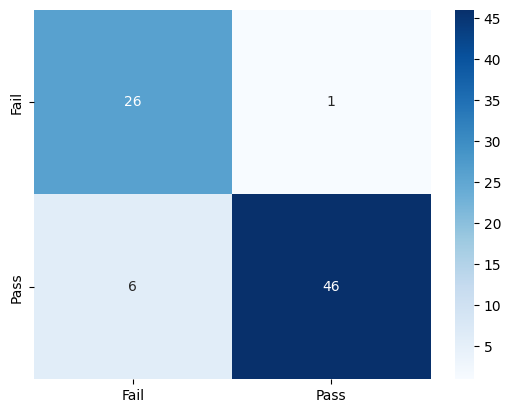

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(b_test, log_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail','Pass'],
            yticklabels=['Fail','Pass'])

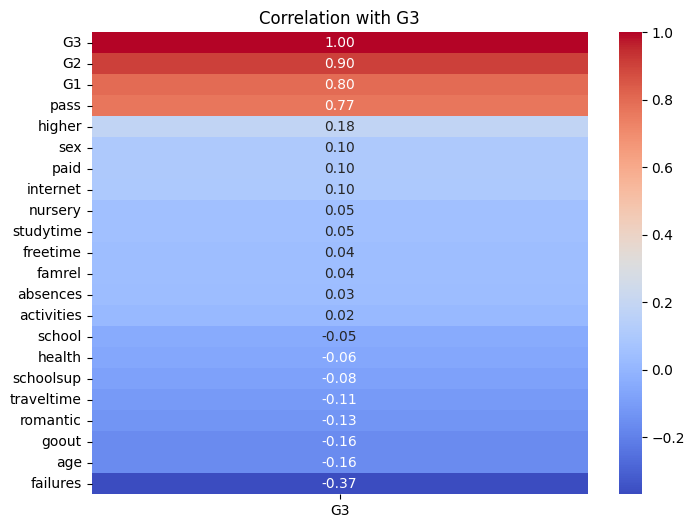

In [ ]:
import matplotlib.pyplot as plt

# Calculate the correlation matrix
corr_matrix = data.corr()

# Get correlations with G3 and sort them
g3_corr = corr_matrix['G3'].sort_values(ascending=False)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(g3_corr.to_frame(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation with G3')
plt.show()